In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout
from tensorflow.keras.datasets import mnist
import tensorflow as tf

In [ ]:
(X_train, y_train), (X_test, y_test)=mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
X_train.shape

(60000, 28, 28)

In [ ]:
X_train=X_train/255.0
X_test=X_test/255.0

In [ ]:
perceptron=Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
perceptron.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
history_perceptron=perceptron.fit(X_train,y_train,epochs=5,batch_size=32,validation_data=(X_test,y_test),verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8788 - loss: 0.4688 - val_accuracy: 0.9146 - val_loss: 0.3065
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9153 - loss: 0.3035 - val_accuracy: 0.9196 - val_loss: 0.2855
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9211 - loss: 0.2835 - val_accuracy: 0.9242 - val_loss: 0.2754
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9236 - loss: 0.2733 - val_accuracy: 0.9247 - val_loss: 0.2693
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9262 - loss: 0.2663 - val_accuracy: 0.9237 - val_loss: 0.2702


In [ ]:
loss,accuracy=perceptron.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9252 - loss: 0.2708


In [ ]:
y_pred=perceptron.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
y_pred_labels=np.argmax(y_pred,axis=1)

In [ ]:
cm=tf.math.confusion_matrix(labels=y_test,predictions=y_pred_labels)

Text(95.72222222222221, 0.5, 'Truth')

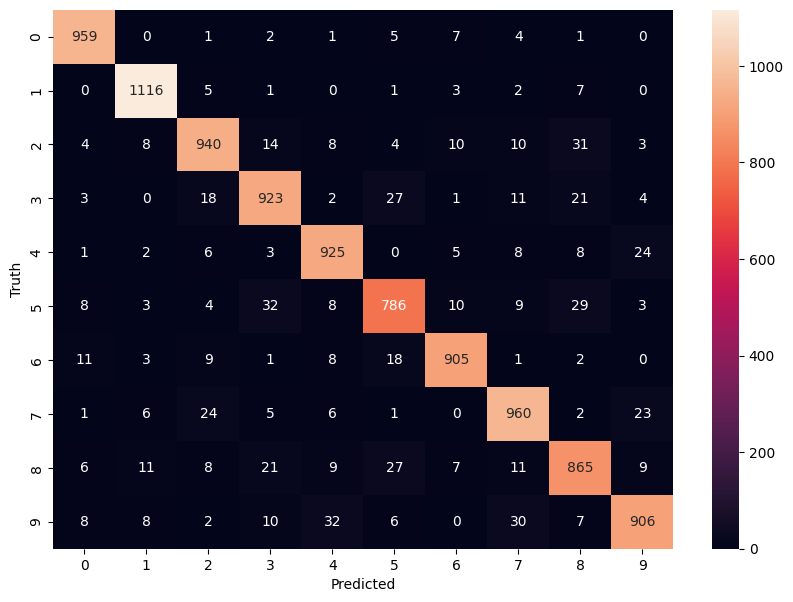

In [ ]:
plt.figure(figsize=(10,7))
sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [ ]:
ann=Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128,activation='relu'),
    Dense(64,activation='relu'),
    Dense(10,activation='softmax')
])

In [ ]:
ann.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
history_ann=ann.fit(X_train,y_train,epochs=5,batch_size=32,validation_data=(X_test,y_test),verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9277 - loss: 0.2449 - val_accuracy: 0.9634 - val_loss: 0.1261
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9689 - loss: 0.1043 - val_accuracy: 0.9674 - val_loss: 0.1013
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9779 - loss: 0.0723 - val_accuracy: 0.9683 - val_loss: 0.1037
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9824 - loss: 0.0572 - val_accuracy: 0.9779 - val_loss: 0.0746
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9862 - loss: 0.0433 - val_accuracy: 0.9770 - val_loss: 0.0824


In [ ]:
loss,accuracy=ann.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9760 - loss: 0.0866


In [ ]:
y_pred=ann.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
y_pred_labels=np.argmax(y_pred,axis=1)

In [ ]:
cm=tf.math.confusion_matrix(labels=y_test,predictions=y_pred_labels)

Text(95.72222222222221, 0.5, 'Truth')

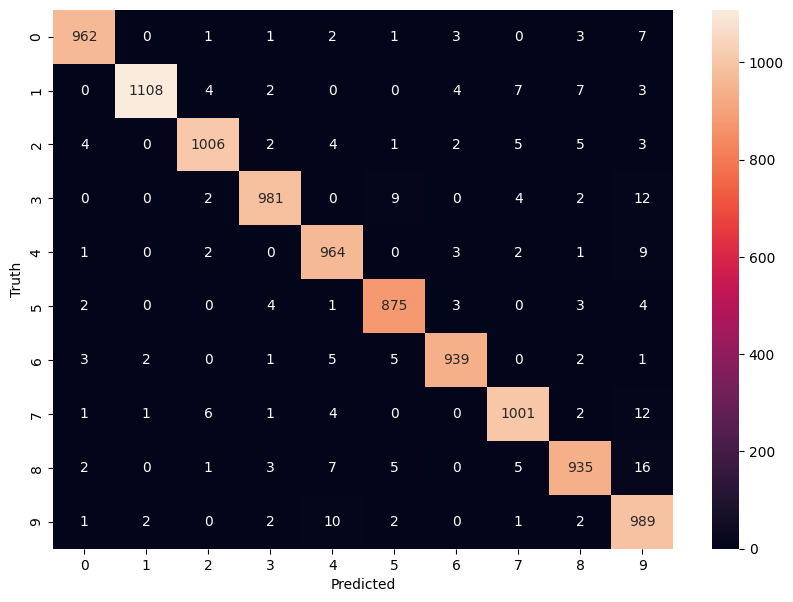

In [ ]:
plt.figure(figsize=(10,7))
sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [ ]:
X_train=X_train.reshape(-1,28,28,1) # 1 represents no of color channels grey scale =1 , for RGB is val is 3
X_test=X_test.reshape(-1,28,28,1) # -1 is placeholder detemine the shape of matrix

In [ ]:
X_train.shape

(60000, 28, 28, 1)

In [ ]:
cnn=Sequential([
    Conv2D(32,kernel_size=(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64,kernel_size=(3,3),activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(10,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
cnn.compile(optimizer='adam',loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
history_cnn=cnn.fit(X_train,y_train,epochs=5,batch_size=32,validation_data=(X_test,y_test),verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 42ms/step - accuracy: 0.9392 - loss: 0.1996 - val_accuracy: 0.9822 - val_loss: 0.0529
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 68s 34ms/step - accuracy: 0.9781 - loss: 0.0734 - val_accuracy: 0.9887 - val_loss: 0.0330
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 54s 29ms/step - accuracy: 0.9839 - loss: 0.0530 - val_accuracy: 0.9909 - val_loss: 0.0288
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 90s 33ms/step - accuracy: 0.9872 - loss: 0.0434 - val_accuracy: 0.9919 - val_loss: 0.0252
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 74s 29ms/step - accuracy: 0.9896 - loss: 0.0354 - val_accuracy: 0.9928 - val_loss: 0.0233


In [ ]:
loss,accuracy=cnn.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9928 - loss: 0.0233


In [ ]:
y_pred=cnn.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


In [ ]:
y_pred_labels=np.argmax(y_pred,axis=1)

In [ ]:
tf.math.confusion_matrix(labels=y_test,predictions=y_pred_labels)

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 976,    1,    1,    0,    0,    0,    0,    0,    1,    1],
       [   0, 1128,    0,    4,    0,    0,    1,    1,    1,    0],
       [   2,    0, 1028,    0,    0,    0,    0,    2,    0,    0],
       [   0,    0,    1, 1007,    0,    1,    0,    0,    1,    0],
       [   0,    0,    0,    0,  972,    0,    4,    0,    0,    6],
       [   0,    0,    0,    6,    0,  883,    1,    1,    0,    1],
       [   2,    2,    0,    0,    1,    1,  952,    0,    0,    0],
       [   0,    2,    3,    1,    0,    0,    0, 1017,    0,    5],
       [   1,    0,    1,    1,    0,    1,    0,    2,  965,    3],
       [   1,    0,    0,    1,    4,    2,    0,    0,    1, 1000]],
      dtype=int32)>

Text(95.72222222222221, 0.5, 'Truth')

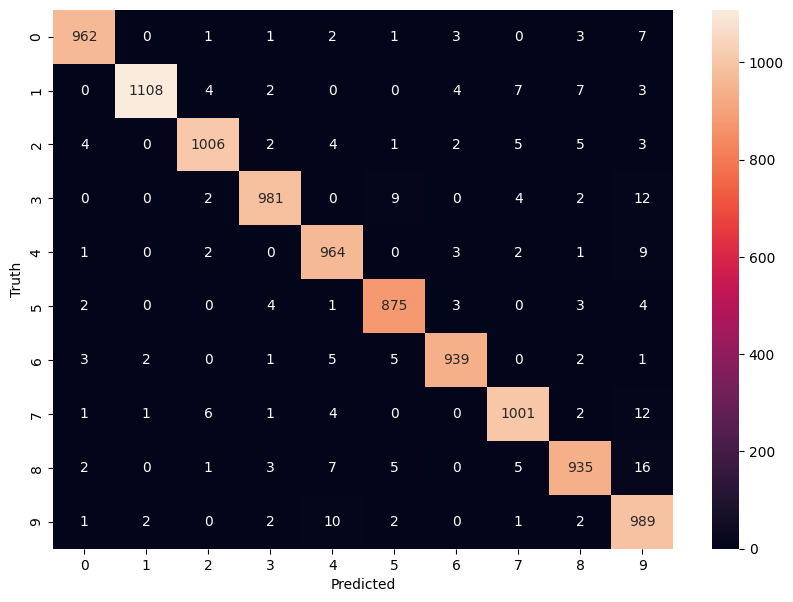

In [ ]:
plt.figure(figsize=(10,7))
sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [ ]:
def plot_training(history,title):
  plt.figure(figsize=(12,4))
  plt.subplot(1,2,1)
  plt.plot(history.history['accuracy'],label='Train')
  plt.plot(history.history['val_accuracy'], label="Validation")
  plt.title(f'{title} Accuracy')

  plt.subplot(1,2,2)
  plt.plot(history.history['loss'],label='Train')
  plt.plot(history.history['val_loss'], label="Validation")
  plt.title(f'{title} Loss')
  plt.legend()
  plt.show()

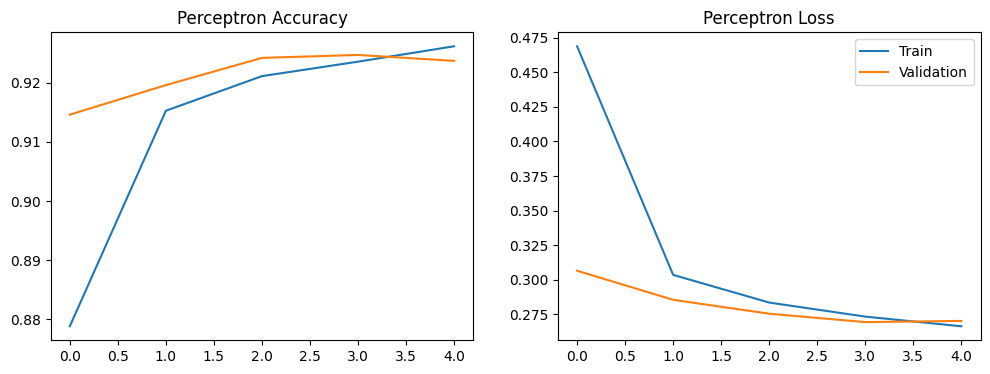

In [ ]:
plot_training(history_perceptron,'Perceptron')

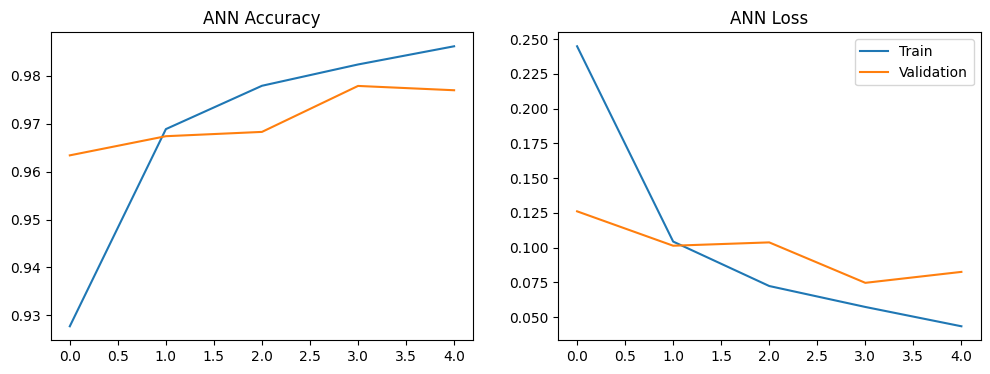

In [ ]:
plot_training(history_ann,'ANN')

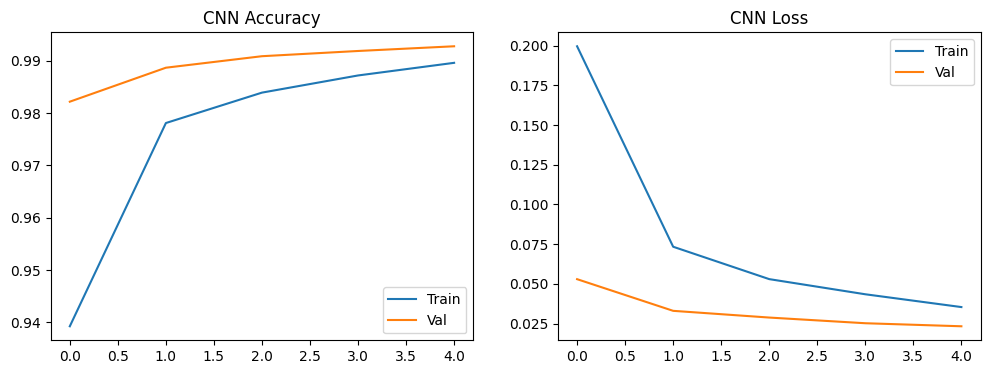

In [ ]:
plot_training(history_cnn,'CNN')

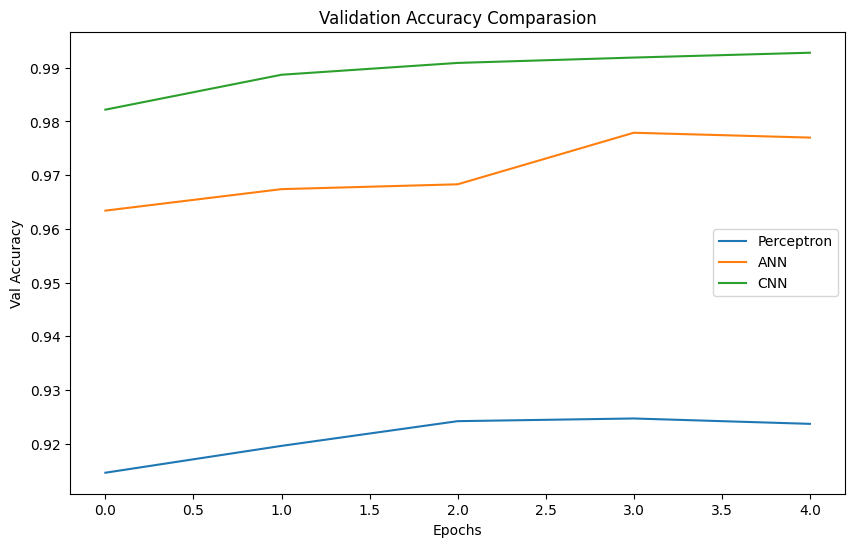

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(history_perceptron.history['val_accuracy'],label='Perceptron')
plt.plot(history_ann.history['val_accuracy'], label="ANN")
plt.plot(history_cnn.history['val_accuracy'], label="CNN")
plt.title('Validation Accuracy Comparasion')
plt.xlabel('Epochs')
plt.ylabel('Val Accuracy')
plt.legend()
plt.show()


In [ ]:
def show_side_by_side(models, model_names, X, X_cnn, y_true, n=5):
    idxs = np.random.choice(len(X), n, replace=False)
    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(idxs):
        plt.subplot(2, n, i+1)
        plt.imshow(X[idx].reshape(28, 28), cmap="gray")
        plt.axis("off")
        plt.title(f"True: {y_true[idx]}")
        preds = [np.argmax(model.predict(X_cnn[idx].reshape(1, 28, 28, 1) if name == "CNN" else X[idx].reshape(1, 28, 28)))
                 for model, name in zip(models, model_names)]
        plt.subplot(2, n, n+i+1)
        plt.axis("off")
        plt.title("\n".join(f"{n}: {p}" for n, p in zip(model_names, preds)))
    plt.tight_layout()
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


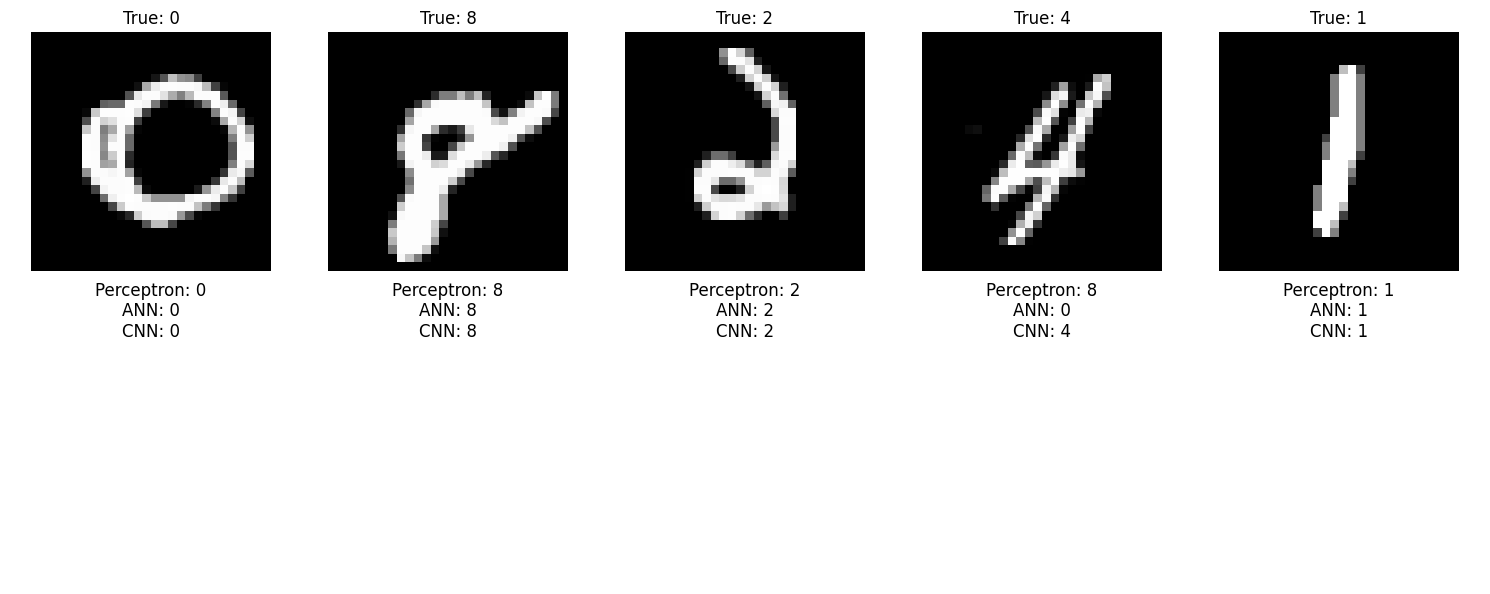

In [ ]:
show_side_by_side([perceptron, ann, cnn], ["Perceptron", "ANN", "CNN"], X_test, X_test, y_test, 5)